In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 5** — Chemical Process Optimisation

Optimising four chemical inputs to maximise factory yield. The function is unimodal — one peak, no traps.

- **Optimisation Goal:** Maximise
- **Input:** 4D
- **All-time best:** 5221.26 at [0.841103, 0.989215, 0.929196, 0.999673]

Loading the cumulative dataset and appending the Week 7 result.

In [3]:
# Load current cumulative dataset (original + prior weekly updates) for Function 5
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy')

# New data for Week 8 (Function 5)
X_w7_new_point = np.array([0.841103, 0.989215, 0.929196, 0.999673], dtype=np.float64)
Y_w7_new_point = np.array([5221.263752299751], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w7_new_point.reshape(1, -1)))

# Remove duplicate X rows
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w7_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_5/initial_outputs.npy', Y_updated)

# Print arrays
print("Updated Inputs (X) - Function 5: ", X_unique)
print("Updated Outputs (Y) - Function 5: ", Y_updated)

Updated Inputs (X) - Function 5:  [[0.004861   0.982935   0.98162    0.958237  ]
 [0.028538   0.096927   0.128764   0.401407  ]
 [0.114475   0.992539   0.999989   0.525254  ]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.19144708 0.03819337 0.60741781 0.41458414]
 [0.221849   0.896815   0.894595   0.898055  ]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.236596   0.865457   0.89289    0.897109  ]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.55421    0.123984   0.678221   0.890122  ]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.67749115 0.35850951 0.

## Output Analysis

- Last week (w6) result of 1728.17 and this week (w7) my result was an all time best of 5221.26.

- **Real-World Implication:** A strong improvement. 
    - The chemical process is responding well to this input profile, very high x2, x3, x4 (all above 0.929) combined with moderate x1 (0.841) is delivering exceptional yield. 
    
    - This is the highest output recorded for F5 across the entire project.

- **Model Clues:** The unimodal nature of this function means we are on or very near the summit. 
    - The w7 profile — high x2/x3/x4, moderate-to-high x1 which is the best candidate for the global peak. 
    
    - The w8 task is micro-tuning: staying extremely close to the w7 coordinates and checking whether marginal adjustments push yield even higher.

- **Key change for W8:** Tighten the focused grid to std=0.01 (from 0.02 implied by the plan) and keep xi=0.001. Do not change the model.

## Bayesian Optimisation — Gaussian Process Regressor

- **Model:** ConstantKernel × Matern (nu=2.5, ARD) + WhiteKernel with Yeo-Johnson output transformation.

- **Changes for W8:**
    - Kernel held constant — the W7 breakthrough validates the architecture completely.

    - Yeo-Johnson transformation retained — the wide output range (142 to 5221) requires it.

- **Intended impact:** Zoom in on the W7 summit and find whether there is a marginal improvement directly adjacent.

In [4]:
# Yeo-Johnson Output Transformation (HEBO)
Y_transformed = power_transform(
    Y_updated.reshape(-1, 1),
    method='yeo-johnson'
).ravel()

print('Original Y:   ', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = C(1.0) * Matern(length_scale=[0.1, 0.1, 0.1, 0.1], nu=2.5) + \
         WhiteKernel(noise_level=1e-5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=25,
    normalize_y=False
)

model.fit(X_unique, Y_transformed)
print('\nFitted kernel:', model.kernel_)

Original Y:    [3.47588113e+03 1.42925081e+02 1.72816974e+03 4.31612757e+02
 9.97233189e+00 8.84799176e+00 6.44434399e+01 1.52269614e+03
 1.08885962e+03 1.33955718e+03 6.34767158e+01 1.09571876e+02
 4.51815703e+01 1.12939795e-01 3.55806818e+02 2.33223610e+02
 7.97291299e+01 5.75715369e+01 1.55727657e+02 6.44201468e+01
 2.44230883e+01 7.84343889e+01 4.21089813e+00 2.88667516e+01
 1.83013796e+01 2.58370525e+02 5.22126375e+03]
Transformed Y: [ 1.71775469  0.09119096  1.35573189  0.64639758 -1.17944678 -1.23197464
 -0.30197939  1.29048604  1.11812801  1.22453932 -0.30936859 -0.04073512
 -0.47472663 -2.27711368  0.54868787  0.33597419 -0.19761555 -0.35703032
  0.13392369 -0.30215616 -0.76887675 -0.20566314 -1.5398858  -0.68970054
 -0.90392928  0.38741402  1.92997409]

Fitted kernel: 1.87**2 * Matern(length_scale=[2.36, 0.512, 1.33, 0.702], nu=2.5) + WhiteKernel(noise_level=1e-05)


/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 4/Week Function Analysis/.venv/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### **Acquisition Function**: EI (xi=0.001) with very tight focused grid

- **Strategy:** EI with xi=0.001 maintained. 
    - Ultra-greedy exploitation is correct for a confirmed unimodal function.

- **Key change for w8:** Very tight focused grid centred on the w7 best [0.841, 0.989, 0.929, 1.000] with std=0.01 which is tighter than any previous week. 
    - This is the micro-tuning phase. 
    - An 80/20 focused/uniform split.

- **Intended impact:** Push yield above 5221 by finding the exact summit of the unimodal hill.

In [5]:
def expected_improvement(X, model, y_max, xi=0.001):
    mu, sigma = model.predict(X, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0] = 0.0
    return ei.ravel()

# Very tight focused grid centred on W7 all-time best
w7_best = np.array([0.841103, 0.989215, 0.929196, 0.999673])

x_focused = np.clip(
    np.random.normal(loc=w7_best, scale=0.01, size=(24000, 4)),
    0.000001, 0.999999
)
x_uniform = np.random.uniform(0.000001, 0.999999, (6000, 4))
x_grid = np.vstack([x_focused, x_uniform])

y_max = np.max(Y_transformed)
ei_values = expected_improvement(x_grid, model, y_max, xi=0.001)
next_query = x_grid[np.argmax(ei_values)]

print(f'W7 best coordinates: {w7_best}')
print(f'Strategic Week 8 Query (Function 5): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

W7 best coordinates: [0.841103 0.989215 0.929196 0.999673]
Strategic Week 8 Query (Function 5): 0.845525-0.999999-0.964822-0.999561


## **Visualisation** - Optimisation Progress

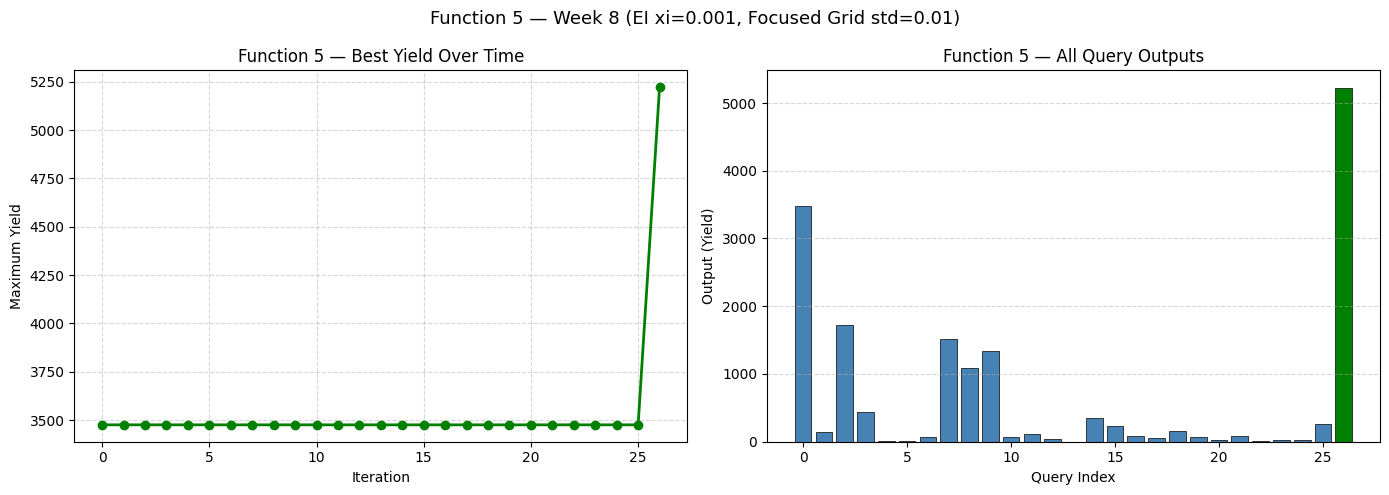

In [6]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(running_max, marker='o', color='green', linewidth=2)
axes[0].set_title('Function 5 — Best Yield Over Time')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Maximum Yield')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bar chart of all query outputs to show trajectory
weekly_labels = [f'W{i+1}' if i < len(Y_updated) else '' for i in range(len(Y_updated))]
colors = ['green' if y == np.max(Y_updated) else 'steelblue' for y in Y_updated]
axes[1].bar(range(len(Y_updated)), Y_updated, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Function 5 — All Query Outputs')
axes[1].set_xlabel('Query Index')
axes[1].set_ylabel('Output (Yield)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 5 — Week 8 (EI xi=0.001, Focused Grid std=0.01)', fontsize=13)
plt.tight_layout()
plt.show()